# 09 — MLP: RNA-only vs Protein-only 

## Environment setup (Colab or local)

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q torch-geometric rdkit
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics_project


## GPU check

In [60]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected — these models will be slow on CPU. "
          "Runtime > Change runtime type > GPU, then re-run this cell.")

Device: cuda


## Imports and config

In [71]:
import json
import time

import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch_geometric.data import Batch, Data
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.metrics import r2_score, roc_auc_score
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import GroupShuffleSplit 
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [36]:
DATA_DIR = BASE_PATH / "data" / "GDSC2"
PROCESSED_DIR = BASE_PATH / "data" / "processed"
SPLITS_DIR = BASE_PATH / "data" / "splits"
RESULTS_DIR = BASE_PATH / "results" / "custom_dl"

COL_CELL_LINE = "cell_line_name"
COL_DRUG = "drug_name"
COL_IC50 = "LN_IC50"
COL_CELLOSAURUS = "cellosaurus_id"
COL_TISSUE = "tissue"

SPLIT_TYPES = ["lpo", "lco", "ldo", "lto"]
ARMS = ["rna", "protein"]

VALIDATION_RATIO = 0.1
TOP_K_FEATURES = 1000
RANDOM_STATE = 42

# Quick smoke test before committing to the full grid: limits to LCO, fold 0 only.
QUICK_TEST = True

## Load response pairs + splits (from notebook 04)

In [5]:
pairs = pd.read_parquet(PROCESSED_DIR / "response_pairs.parquet")

with open(SPLITS_DIR / "splits.json") as f:
    folds = json.load(f)

with open(SPLITS_DIR / "holdout_groups.json") as f:
    holdout_groups = json.load(f)

print(f"{len(pairs)} pairs loaded")
for fd in folds:
    print(f"fold {fd['fold']}: train={len(fd['train']):,} | "
          f"lco_test={len(fd['lco_test']):,} | ldo_test={len(fd['ldo_test']):,} | "
          f"lto_test={len(fd['lto_test']):,} | lpo_test={len(fd['lpo_test']):,}")

# holdout_groups.json: which cell lines / drugs / tissues were actually held
# out per fold (entity IDs, not row indices) -- needed later to interpret
# results (e.g. which tissues drove a fold's LTO test set, whether the same
# drugs/cell lines are consistently hard across folds). Not used by the
# training/eval loops below, just loaded here so it's available alongside
# everything else.
with open(SPLITS_DIR / "holdout_groups.json") as f:
    holdout_groups = json.load(f)

for g in holdout_groups:
    print(f"fold {g['fold']}: {len(g['cell_lines_held_out'])} cell lines, "
          f"{len(g['drugs_held_out'])} drugs, "
          f"{len(g['tissues_held_out'])} tissues held out")

176197 pairs loaded
fold 0: train=93,176 | lco_test=17,470 | ldo_test=18,404 | lto_test=25,964 | lpo_test=41,225
fold 1: train=106,127 | lco_test=17,331 | ldo_test=18,515 | lto_test=13,579 | lpo_test=32,950
fold 2: train=82,134 | lco_test=18,173 | ldo_test=18,126 | lto_test=35,198 | lpo_test=47,665
fold 3: train=97,788 | lco_test=17,849 | ldo_test=18,140 | lto_test=21,451 | lpo_test=38,293
fold 4: train=88,673 | lco_test=17,762 | ldo_test=18,533 | lto_test=28,869 | lpo_test=43,443
fold 0: 84 cell lines, 25 drugs, 3 tissues held out
fold 1: 84 cell lines, 25 drugs, 3 tissues held out
fold 2: 84 cell lines, 25 drugs, 3 tissues held out
fold 3: 84 cell lines, 25 drugs, 3 tissues held out
fold 4: 84 cell lines, 25 drugs, 3 tissues held out


## Load omics features, drug fingerprints, and drug graphs

Fingerprints feed `SimpleNeuralNetwork`; graphs feed `DrugGNN`. Graph builder
matches `PLAN.md`'s original `smiles_to_graph` design (atom features: atomic
number, degree, formal charge, hybridization, aromaticity, H count).

In [6]:
rna = pd.read_csv(DATA_DIR / "gene_expression.csv", index_col=0)
protein = pd.read_csv(DATA_DIR / "proteomics.csv", index_col=0)
drug_smiles = pd.read_csv(DATA_DIR / "drug_smiles.csv")

rna = rna[~rna.index.duplicated(keep="first")].iloc[:, 1:]
protein = protein[~protein.index.duplicated(keep="first")]

OMICS = {"rna": rna, "protein": protein}

In [7]:
print(f"RNA: {rna.shape[1]} Genes / {rna.shape[0]} cell lines")
print(f"Protein:      {protein.shape[1]} Proteins / {protein.shape[0]} cell lines")
print(f"Drugs:        {drug_smiles[COL_DRUG].nunique()} drugs")

RNA: 17737 Genes / 1010 cell lines
Protein:      6692 Proteins / 860 cell lines
Drugs:        246 drugs


In [8]:

def build_drug_fingerprints(drug_smiles_df: pd.DataFrame, radius: int = 2, n_bits: int = 2048) -> dict:
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = {}
    for _, row in drug_smiles_df.iterrows():
        mol = Chem.MolFromSmiles(row["canonical_smiles"])
        if mol is None:
            continue
        fp = generator.GetFingerprint(mol)
        fps[row[COL_DRUG]] = np.array(fp, dtype=np.float32)
    return fps


def atom_to_features(atom) -> list[float]:
    return [
        atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
        int(atom.GetHybridization()), int(atom.GetIsAromatic()), atom.GetTotalNumHs(),
    ]


def smiles_to_graph(smiles: str) -> Data | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    x = torch.tensor([atom_to_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)


def build_drug_graphs(drug_smiles_df: pd.DataFrame) -> dict:
    graphs = {}
    for _, row in drug_smiles_df.iterrows():
        g = smiles_to_graph(row["canonical_smiles"])
        if g is not None:
            graphs[row[COL_DRUG]] = g
    return graphs


In [9]:
drug_fp = build_drug_fingerprints(drug_smiles)
# drug_graphs = build_drug_graphs(drug_smiles)

In [10]:
print(f"Fingerprints: {drug_fp['Romidepsin'].shape[0]} features / {drug_smiles[COL_DRUG].nunique()} drugs")
# print(f"Graphs:       {len(drug_graphs)} / {drug_smiles[COL_DRUG].nunique()} drugs")

Fingerprints: 2048 features / 246 drugs


## Split Train/Val

In [11]:
def make_validation_indices(train_idx: np.ndarray, fraction: float = VALIDATION_RATIO, seed: int = RANDOM_STATE) -> tuple[np.ndarray, np.ndarray]:
    """Mirrors the outer fold construction: hold out a small fraction of cell
    lines, drugs, and tissues independently from train, same as notebook 04.
    val = anything touching one of those holdouts, train_inner = the rest."""
    sub = pairs.loc[train_idx]

    def axis_holdout(group_values: pd.Series, seed_offset: int) -> set:
        gss = GroupShuffleSplit(n_splits=1, test_size=fraction, random_state=seed + seed_offset)
        idx = np.arange(len(group_values))
        _, val_idx = next(gss.split(idx, groups=group_values))
        return set(group_values.iloc[val_idx])

    cell_holdout = axis_holdout(sub[COL_CELLOSAURUS], 0)
    drug_holdout = axis_holdout(sub[COL_DRUG], 1)
    tissue_holdout = axis_holdout(sub[COL_TISSUE], 2)

    is_val = (
        sub[COL_CELLOSAURUS].isin(cell_holdout)
        | sub[COL_DRUG].isin(drug_holdout)
        | sub[COL_TISSUE].isin(tissue_holdout)
    ).to_numpy()

    val_idx = train_idx[is_val]
    train_inner_idx = train_idx[~is_val]
    return train_inner_idx, val_idx

In [12]:
train_inner_idx, val_idx = make_validation_indices(np.array(folds[0]["train"]))

In [13]:
print('Train indices:', len(train_inner_idx), '/ Validation indices:', len(val_idx))

Train indices: 68682 / Validation indices: 24494


## Feature builders

`build_feature_matrix` (omics + fingerprint, concatenated) feeds `SimpleNeuralNetwork`
— same shape as notebook 07's sklearn baselines. `build_omics_matrix` (omics only,
drug kept separate as a graph reference) feeds `DrugGNN`.

In [20]:
def build_feature_matrix(idx: np.ndarray, arm: str) -> tuple[np.ndarray, np.ndarray]:
    sub = pairs.loc[idx]
    omics_X = OMICS[arm].loc[sub[COL_CELLOSAURUS]].to_numpy()
    drug_X = np.vstack([drug_fp[d] for d in sub[COL_DRUG]])
    X = np.hstack([omics_X, drug_X]).astype(np.float32)
    y = sub[COL_IC50].to_numpy().astype(np.float32)
    return X, y


def build_omics_matrix(idx: np.ndarray, arm: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    sub = pairs.loc[idx]
    X = OMICS[arm].loc[sub[COL_CELLOSAURUS]].to_numpy().astype(np.float32)
    y = sub[COL_IC50].to_numpy().astype(np.float32)
    drug_ids = sub[COL_DRUG].to_numpy()
    return X, y, drug_ids


def select_top_variance_columns(X_ref: np.ndarray, k: int, n_extra_cols: int = 0) -> np.ndarray:
    """Top-k highest-variance omics columns, computed from X_ref only. n_extra_cols
    accounts for a concatenated drug fingerprint that's always kept (not variance-selected)."""
    n_omics = X_ref.shape[1] - n_extra_cols
    variances = X_ref[:, :n_omics].var(axis=0)
    top_idx = np.argsort(variances)[-k:]
    return np.concatenate([top_idx, np.arange(n_omics, X_ref.shape[1])])

## DataLoader preparation

In [14]:
def build_mlp_inputs(idx: np.ndarray, arm_rna: str = "rna", arm_protein: str = "protein") -> tuple[np.ndarray, ...]:
    sub = pairs.loc[idx]
    print(f"Preparing rna inputs")
    rna_X = OMICS[arm_rna].loc[sub[COL_CELLOSAURUS]].to_numpy().astype(np.float32)
    print(f"Preparing protein inputs")
    protein_X = OMICS[arm_protein].loc[sub[COL_CELLOSAURUS]].to_numpy().astype(np.float32)
    print(f"Preparing drug inputs")
    drug_X = np.vstack([drug_fp[d] for d in sub[COL_DRUG]]).astype(np.float32)
    print(f"Preparing target values")
    y = sub[COL_IC50].to_numpy().astype(np.float32)
    return rna_X, protein_X, drug_X, y


def make_dataloader(rna_X, protein_X, drug_X, y, batch_size, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(rna_X),
        torch.from_numpy(protein_X),
        torch.from_numpy(drug_X),
        torch.from_numpy(y),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)

In [15]:
rna_X_train, protein_X_train, drug_X_train, y_train = build_mlp_inputs(train_inner_idx)

Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [16]:
rna_X_val, protein_X_val, drug_X_val, y_val = build_mlp_inputs(val_idx)

Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [56]:
rna_X_lco_test, protein_X_lco_test, drug_X_lco_test, y_lco_test = build_mlp_inputs(np.array(folds[0]['lco_test']))
rna_X_ldo_test, protein_X_ldo_test, drug_X_ldo_test, y_ldo_test = build_mlp_inputs(np.array(folds[0]['ldo_test']))
rna_X_lpo_test, protein_X_lpo_test, drug_X_lpo_test, y_lpo_test = build_mlp_inputs(np.array(folds[0]['lpo_test']))
rna_X_lto_test, protein_X_lto_test, drug_X_lto_test, y_lto_test = build_mlp_inputs(np.array(folds[0]['lto_test']))

Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values
Preparing rna inputs
Preparing protein inputs
Preparing drug inputs
Preparing target values


In [17]:
train_loader = make_dataloader(rna_X_train, protein_X_train, drug_X_train, y_train, batch_size=64, shuffle=True)
val_loader = make_dataloader(rna_X_val, protein_X_val, drug_X_val, y_val, batch_size=64, shuffle=False)

In [18]:
for input_rna, input_prot, input_drug, ic50_out in val_loader:
    print("RNA input shape:", input_rna.shape)
    print("Protein input shape:", input_prot.shape)
    print("Drug input shape:", input_drug.shape)
    print("IC50 output shape:", ic50_out.shape)
    break

RNA input shape: torch.Size([64, 17737])
Protein input shape: torch.Size([64, 6692])
Drug input shape: torch.Size([64, 2048])
IC50 output shape: torch.Size([64])


In [19]:
for i, data in enumerate(val_loader):
    print(f"Batch {i+1}:")
    input_rna, input_prot, input_drug, ic50_out = data
    print("RNA input shape:", input_rna.shape)
    print("Protein input shape:", input_prot.shape)
    print("Drug input shape:", input_drug.shape)
    print("IC50 output shape:", ic50_out.shape)
    break

Batch 1:
RNA input shape: torch.Size([64, 17737])
Protein input shape: torch.Size([64, 6692])
Drug input shape: torch.Size([64, 2048])
IC50 output shape: torch.Size([64])


In [20]:
data_loaders = {"train": train_loader, "val": val_loader}

## `SimpleNeuralNetwork` architecture and training

Architecture matches `FeedForwardNetwork` exactly: each hidden layer is
Linear → BatchNorm → Dropout → ReLU, **except the last hidden layer**, which is
just Linear → ReLU (no BN/dropout) before the final unactivated output layer —
that asymmetry is in the original code, not a simplification here. `dropout_prob=0.3`
and `max_epochs=100` are fixed (drevalpy's yaml lists one value for each, so they're
not actually tuned); `units_per_layer` is the real grid dimension (4 architectures);
`batch_size=32`, `patience=5`, Adam with default `lr=1e-3` all match upstream.

Models to try:
- Single modal:
    1. rna only 
    2. protein only
    3. drugs fp only
    4. drugs graph only
- Multi modal:
    
    5. rna + drugs fp 
    6. protein + drugs fp 
    7. rna + protein + drugs fp
    
    8. rna + drugs graph 
    9. protein + drugs graph 
    10. rna + protein + drugs graph

same archi for all single modal

multi modal integration:
    - simple concatenation 
    - processing each modality into the same dim then we concat (simple) and Cross-attention fusion
    - we also need an architecture to account for relationships between this modalities, rna as input protein as output?? if learned the relationships between these 2 layers of biology in case of missing data in one cell line we can impute? 
    - what about relatopnship between biology and drugs, is there a relationships that can be playing a role that we don't pay attention too? how can we account for such relationships? basicly it is the relationships between rna features (or protein or both) and the drugs features that will led to the response? can we detect 3 ways relationships between rna / drugs/ ic50?


**KEEP MODELS AS SIMPLEST AS THEY CAN BE**

In [21]:
class NN1Omics(nn.Module):
    def __init__(self, input_dim, hidden_layers: list[int], dropout_prob: float = 0.3):
        super().__init__()
        self.fc_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()

        self.fc_layers.append(nn.Linear(input_dim, hidden_layers[0]))
        self.bn_layers.append(nn.BatchNorm1d(hidden_layers[0]))
        for i in range(1, len(hidden_layers)):
            self.fc_layers.append(nn.Linear(hidden_layers[i - 1], hidden_layers[i]))
            self.bn_layers.append(nn.BatchNorm1d(hidden_layers[i]))
        self.fc_layers.append(nn.Linear(hidden_layers[-1], 1))
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        for i in range(len(self.fc_layers) - 2):
            x = self.fc_layers[i](x)
            x = self.bn_layers[i](x)
            x = self.dropout(x)
            x = F.relu(x)
        x = F.relu(self.fc_layers[-2](x))
        x = self.fc_layers[-1](x)
        return x.squeeze(-1)

In [22]:
input_dim_rna = rna_X_train.shape[1]
input_dim_protein = protein_X_train.shape[1]
input_dim_drug = drug_X_train.shape[1]

hidden_layers = [256]

In [27]:
rna_model = NN1Omics(input_dim=input_dim_rna, hidden_layers=hidden_layers)
protein_model = NN1Omics(input_dim=input_dim_protein, hidden_layers=hidden_layers)
drug_model = NN1Omics(input_dim=input_dim_drug, hidden_layers=hidden_layers)

In [28]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [29]:
print(f"RNA model parameters: {count_parameters(rna_model):,}")
print(f"Protein model parameters: {count_parameters(protein_model):,}")
print(f"Drug model parameters: {count_parameters(drug_model):,}")

RNA model parameters: 4,541,697
Protein model parameters: 1,714,177
Drug model parameters: 525,313


In [30]:
drug_out_test = drug_model(input_drug)

In [31]:
drug_out_test.shape

torch.Size([64])

In [32]:
criterion = nn.HuberLoss()
optimizer_rna = torch.optim.Adam(rna_model.parameters(), lr= 1e-4, weight_decay = 1e-4)
optimizer_protein = torch.optim.Adam(protein_model.parameters(), lr= 1e-4, weight_decay = 1e-4)
optimizer_drug = torch.optim.Adam(drug_model.parameters(), lr= 1e-4, weight_decay = 1e-4)

In [ ]:
def fit_mlp(model, data_loaders, optimizer, criterion, num_epochs, patience, checkpoint_path, device, input_modality):
    """input_modality: list of "rna", "protein", "drug" in any combination,
    e.g. ["rna"], ["rna", "protein"], ["rna", "protein", "drug"]."""
    history = {"train_loss": [], "train_cor": [], "val_loss": [], "val_cor": []}

    best_val_mse = float("inf")
    best_weights = None
    wait = 0
    stop_training = False

    print("Starting training...")
    for epoch in range(num_epochs):
        if stop_training:
            break
        print(f"Epoch {epoch + 1}/{num_epochs}")

        for phase in ["val", "train"]:
            phase_device = device if phase == "train" else torch.device("cpu")
            model.to(phase_device)
            model.train() if phase == "train" else model.eval()

            batch_losses = []
            preds, targets = [], []

            for input_rna, input_prot, input_drug, ic50_out in tqdm(
                data_loaders[phase], total=len(data_loaders[phase]), desc=phase
            ):
                modality_tensors = {"rna": input_rna, "protein": input_prot, "drug": input_drug}
                x = torch.cat([modality_tensors[m] for m in input_modality], dim=1).to(phase_device)
                # input_rna = input_rna.to(phase_device)
                # input_prot = input_prot.to(phase_device)
                # input_drug = input_drug.to(phase_device)
                ic50_out = ic50_out.to(phase_device)

                if phase == "train":
                    optimizer.zero_grad()
                    pred = model(x)
                    loss = criterion(pred, ic50_out)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        pred = model(x)
                        loss = criterion(pred, ic50_out)

                batch_losses.append(loss.item())
                preds.append(pred.detach())
                targets.append(ic50_out.detach())

            epoch_mse = sum(batch_losses) / len(batch_losses)
            all_preds = torch.cat(preds).cpu().numpy()
            all_targets = torch.cat(targets).cpu().numpy()
            epoch_cor, _ = pearsonr(all_targets, all_preds)

            history[f"{phase}_loss"].append(epoch_mse)
            history[f"{phase}_cor"].append(epoch_cor)
            print(f"  {phase}: loss={epoch_mse:.4f}  pearson_r={epoch_cor:.4f}")

            if phase == "val":
                if epoch_mse < best_val_mse:
                    best_val_mse = epoch_mse
                    best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f"Early stopping at epoch {epoch + 1}")
                        stop_training = True

    if best_weights is not None:
        model.load_state_dict(best_weights)
        torch.save(best_weights, checkpoint_path)
        print(f"Best val Loss: {best_val_mse:.4f} -- saved to {checkpoint_path}")

    model
    return model, history

In [43]:
num_epochs = 3
patience = 5
checkpoint_path = RESULTS_DIR / "checkpoints/mlp_drug_fp_model.pt"

In [44]:
checkpoint_path

PosixPath('/content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/mlp_drug_fp_model.pt')

In [45]:
drug_model, drug_history = fit_mlp(drug_model, data_loaders, optimizer_drug, criterion, num_epochs, patience, checkpoint_path, DEVICE, ["drug"])

Starting training...
Epoch 1/3


train:   0%|          | 0/1073 [00:00<?, ?it/s]

  train: loss=0.7131  pearson_r=0.8290


val:   0%|          | 0/383 [00:00<?, ?it/s]

  val: loss=1.1093  pearson_r=0.6087
Epoch 2/3


...

  val: loss=1.1051  pearson_r=0.6091
Epoch 3/3


train:   0%|          | 0/1073 [00:00<?, ?it/s]

  train: loss=0.7121  pearson_r=0.8293


val:   0%|          | 0/383 [00:00<?, ?it/s]

  val: loss=1.1069  pearson_r=0.6047
Best val Loss: 1.1051 -- saved to /content/drive/MyDrive/multiomics_project/results/custom_dl/checkpoints/mlp_drug_fp_model.pt


## Plot loss

In [46]:
drug_history.keys()

dict_keys(['train_loss', 'train_cor', 'val_loss', 'val_cor'])

In [48]:
def plot_learning_curve(training_loss, val_loss, title):
    plt.subplots(figsize=(7, 4))
    plt.plot(training_loss) 
    plt.plot(val_loss)
    plt.title(title)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show() 

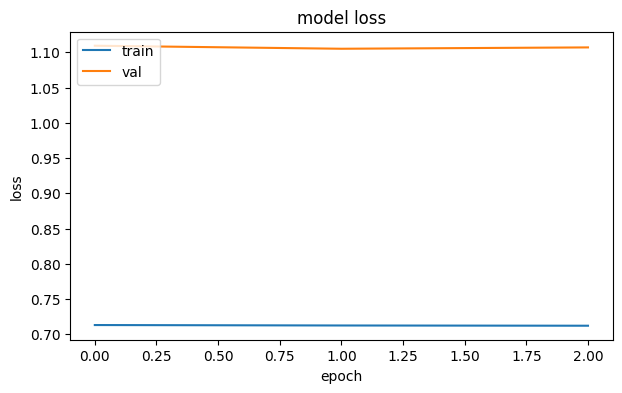

In [49]:
plot_learning_curve(drug_history['train_loss'], drug_history['val_loss'], 'model loss')


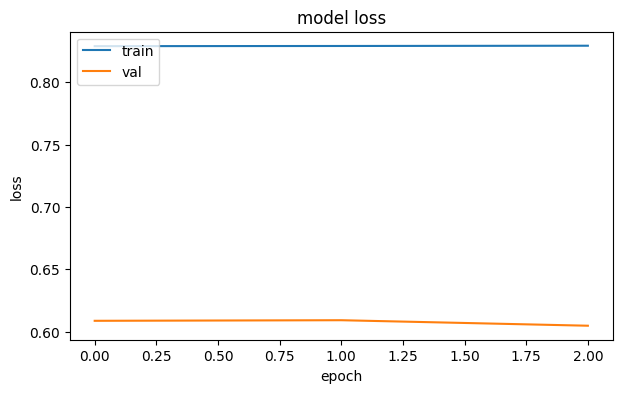

In [50]:
plot_learning_curve(drug_history['train_cor'], drug_history['val_cor'], 'model loss')

## Prediction

In [59]:
def predict(model, x, device='cpu', batch_size=512):
    """x: numpy array or tensor of features (already built, single modality).
    Returns predictions as a 1D numpy array."""
    model.to(device)
    model.eval()
    if not torch.is_tensor(x):
        x = torch.from_numpy(x)
    preds = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            xb = x[i:i + batch_size].to(device)
            preds.append(model(xb).cpu())
    return torch.cat(preds).numpy()



In [62]:
dm_drug_pred_lco_test = predict(drug_model, drug_X_lco_test)
dm_drug_pred_ldo_test = predict(drug_model, drug_X_ldo_test)
dm_drug_pred_lto_test = predict(drug_model, drug_X_lto_test)
dm_drug_pred_lpo_test = predict(drug_model, drug_X_lpo_test)

In [64]:
dm_drug_pred_lco_test

array([-3.1379077, -5.164714 , -3.1379077, ...,  9.993193 ,  9.993192 ,
        9.993192 ], dtype=float32)

## Evaluation

In [72]:
def evaluateMT(target, pred, threshold=None):
    """
    threshold: cutoff for binarizing target into sensitive/resistant for ROC-AUC.
    Defaults to median of target if not provided.
    """
    variance_real = np.var(target)
    variance_pred = np.var(pred)
    mean_real = np.mean(target)
    mean_pred = np.mean(pred)
    mses = ((target - pred)**2).mean(axis=0)
    rmse = np.sqrt(mses)
    correlation, corr_p_value = pearsonr(target, pred)
    spearman_corr, spearman_p = spearmanr(target, pred)
    r2 = r2_score(target, pred)
    slope, intercept, r_value, lr_p_value, std_err = linregress(pred, target)

    if threshold is None:
        threshold = np.median(target)
    target_binary = (target < threshold).astype(int)  # 1 = sensitive (lower IC50)
    if len(np.unique(target_binary)) == 2:
        roc_auc = roc_auc_score(target_binary, -pred)  # lower predicted IC50 = more sensitive
    else:
        roc_auc = np.nan  # all-one-class fold, AUC undefined

    results = {
        'Correlation': round(correlation, 2),
        'Corr p-value': round(corr_p_value, 4),
        'Spearman': round(spearman_corr, 2),
        'MSE': round(mses, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 2),
        'ROC-AUC': round(roc_auc, 2) if not np.isnan(roc_auc) else roc_auc,
        'Slope': round(slope, 2),
        'Standard error': round(std_err, 2),
        'Variance Real': round(variance_real, 2),
        'Variance Pred': round(variance_pred, 2)
    }

    return pd.DataFrame([results])

In [75]:
splits = {
    'LCO': (y_lco_test, dm_drug_pred_lco_test),
    'LTO': (y_lto_test, dm_drug_pred_lto_test),
    'LPO': (y_lpo_test, dm_drug_pred_lpo_test),
    'LDO': (y_ldo_test, dm_drug_pred_ldo_test),
}

results_list = []
for split_name, (y_true, y_pred) in splits.items():
    df = evaluateMT(y_true, y_pred)
    df.insert(0, 'Split', split_name)
    results_list.append(df)

results_df = pd.concat(results_list, ignore_index=True)
results_df


,Split,Correlation,Corr p-value,Spearman,MSE,RMSE,R2,ROC-AUC,Slope,Standard error,Variance Real,Variance Pred
0,LCO,0.73,0.0,0.64,3.40,1.84,0.53,0.82,0.93,0.01,7.16,4.38
1,LTO,0.74,0.0,0.66,4.13,2.03,0.45,0.82,0.97,0.01,7.54,4.41
2,LPO,0.74,0.0,0.65,3.35,1.83,0.54,0.82,0.94,0.00,7.29,4.46
3,LDO,0.15,0.0,0.13,6.79,2.61,-0.04,0.54,0.37,0.02,6.52,1.03
